<a href="https://colab.research.google.com/github/D-LukeSherman/ECGR-4105/blob/main/Homework4_Problem2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.svm import SVR
from sklearn.decomposition import PCA as RandomizedPCA
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

In [ ]:
# Use the URL for the raw CSV data
url = 'https://raw.githubusercontent.com/D-LukeSherman/ECGR-4105/refs/heads/main/Homework4/Housing.csv'

dataset = pd.read_csv(url)

# Preprocessing

varlist = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
            'airconditioning', 'prefarea']

def binary_map(x):
    return x.map({'yes': 1, 'no': 0})

dataset[varlist] = dataset[varlist].apply(binary_map)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_vars = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
            'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']

# dataset[num_vars] = scaler.fit_transform(dataset[num_vars])

display(dataset)

# Separating out the features
x = dataset.iloc[:, 1:12].values
# Separating out the target
y = dataset.iloc[:, 0].values

Xtrain, Xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2,
                                                random_state=0)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,unfurnished
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished


In [ ]:
display(Xtrain)
Xtrain.shape

array([[3620,    2,    1, ...,    0,    0,    0],
       [4000,    2,    1, ...,    0,    0,    0],
       [3040,    2,    1, ...,    0,    0,    0],
       ...,
       [5750,    3,    2, ...,    1,    1,    1],
       [3600,    3,    1, ...,    0,    1,    0],
       [6600,    3,    1, ...,    0,    0,    1]])

(436, 11)

In [ ]:
svr_rbf = SVR(kernel='rbf', C=1000, gamma=0.1)
svr_lin = SVR(kernel='linear', C=1000)
svr_poly = SVR(kernel='poly', C=1000, degree=2)
y_rbf = svr_rbf.fit(Xtrain, ytrain).predict(Xtest)
y_lin = svr_lin.fit(Xtrain, ytrain).predict(Xtest)
y_poly = svr_poly.fit(Xtrain, ytrain).predict(Xtest)

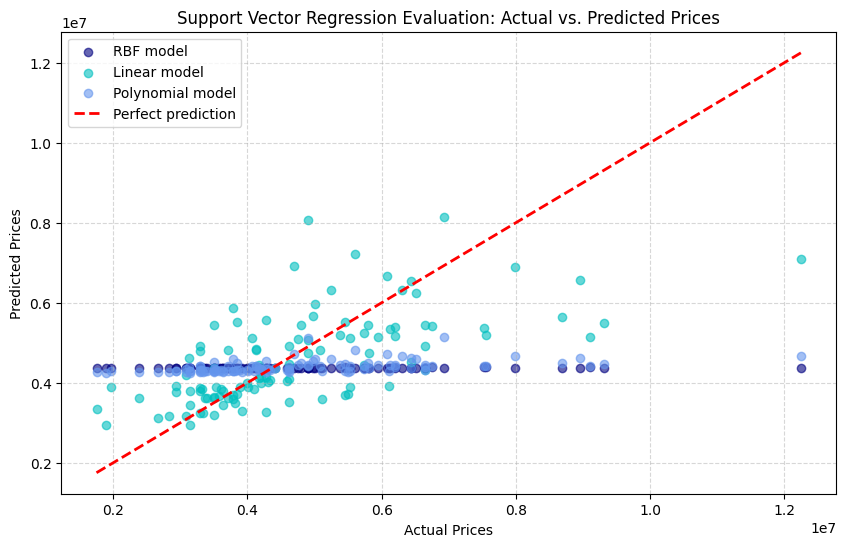

In [ ]:
# Accurate Model Evaluation - Plotting Actual vs Predicted Prices
plt.figure(figsize=(10, 6))

# Scatter plots of predictions vs actual targets for each model
plt.scatter(ytest, y_rbf, color='navy', alpha=0.6, label='RBF model')
plt.scatter(ytest, y_lin, color='c', alpha=0.6, label='Linear model')
plt.scatter(ytest, y_poly, color='cornflowerblue', alpha=0.6, label='Polynomial model')

# Calculate limits for the identity line
all_values = np.concatenate([ytest, y_rbf, y_lin, y_poly])
min_val, max_val = all_values.min(), all_values.max()

# Reference line representing perfect prediction (Actual = Predicted)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Support Vector Regression Evaluation: Actual vs. Predicted Prices')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

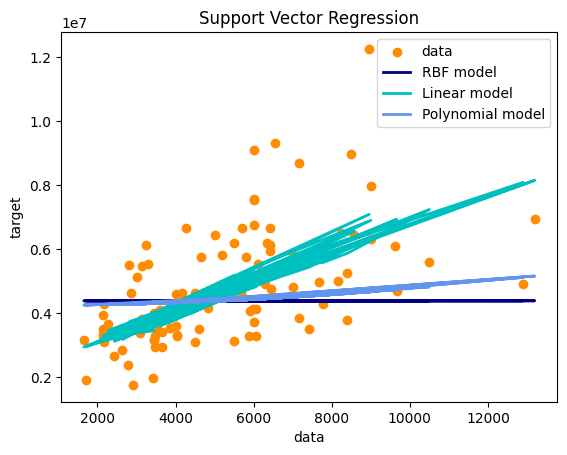

In [ ]:
lw = 2
plt.scatter(Xtest[:, 0], ytest, color='darkorange', label='data')
plt.plot(Xtest[:, 0], y_rbf, color='navy', lw=lw, label='RBF model')
plt.plot(Xtest[:, 0], y_lin, color='c', lw=lw, label='Linear model')
plt.plot(Xtest[:, 0], y_poly, color='cornflowerblue', lw=lw, label='Polynomial model')
plt.xlabel('data')
plt.ylabel('target')
plt.title('Support Vector Regression')
plt.legend()
plt.show()